# Laboratorio 1: Regresión en California

En este laboratorio deben hacer experimentos de regresión con el conjunto de datos "California Housing dataset".

Estudiarán el dataset, harán visualizaciones y seleccionarán atributos relevantes a mano.

Luego, entrenarán y evaluarán diferentes tipos de regresiones, buscando las configuraciones que mejores resultados den.

## Sobre este Trabajo Práctico

El objetivo de este trabajo es que puedas aplicar los conceptos de regresión sobre un dataset real, tomando decisiones propias en cada etapa: qué atributos usar, qué modelo elegir y cómo interpretar los resultados.

No se trata solo de ejecutar el código: se espera que puedas **justificar tus elecciones**, **interpretar los errores obtenidos** y **explicar qué está pasando** en cada experimento.

Al finalizar, deberías poder responder: ¿qué modelo elegirías para este problema y por qué? ¿Cómo reconocés underfitting y overfitting en tus resultados?



In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Carga del Conjunto de Datos

Cargamos el conjunto de datos y vemos su contenido.

In [2]:
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()

In [3]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [4]:

#print(california['DESCR'])  # descripción del dataset
california['feature_names'] # nombres de los atributos para cada columna de 'data'
#california['data']           # matriz con los datos de entrada (atributos)
#print(california['target']) # vector de valores a predecir

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [5]:
california['data'].shape, california['target'].shape

((20640, 8), (20640,))

## División en Entrenamiento y Evaluación

Dividimos aleatoriamente los datos en 80% para entrenamiento y 20% para evaluación:

In [6]:
from sklearn.model_selection import train_test_split
X, y = california['data'], california['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0)
X_train.shape, X_test.shape

((16512, 8), (4128, 8))

In [7]:
y.shape

(20640,)

In [8]:
y_test.shape

(4128,)

## Ejercicio 1: Descripción de los Datos y la Tarea

Responda las siguientes preguntas:

1. ¿De qué se trata el conjunto de datos?
2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?
3. ¿Qué información (atributos) hay disponibles para hacer la predicción?
4. ¿Qué atributos imagina ud. que serán los más determinantes para la predicción?
5. ¿Qué problemas observa a priori en el conjunto de datos? ¿Observa posibles sesgos, riesgos, dilemas éticos, etc? Piense que los datos pueden ser utilizados para hacer predicciones futuras.

**No hace falta escribir código para responder estas preguntas.**

### Respuestas

**1. ¿De qué se trata el conjunto de datos?**
Son datos del censo de EE.UU. de **1990** agregados por *block group* (la unidad geográfica más chica del censo, ~600–3000 habitantes) en el estado de California. Cada fila describe un block group con características socioeconómicas y de vivienda promedio.

**2. ¿Cuál es la variable objetivo? ¿Qué significa?**
El target es el **valor medio de las viviendas** del block group, expresado en **cientos de miles de dólares** (un `1.0` = USD 100.000). Está **truncado en 5.0** (los valores ≥ \$500k se cortan ahí), lo cual ya anticipa un problema: el modelo nunca va a poder predecir bien las zonas más caras.

**3. ¿Qué atributos hay disponibles?**
- `MedInc`: ingreso mediano del block group.
- `HouseAge`: antigüedad mediana de las viviendas.
- `AveRooms` / `AveBedrms`: promedio de habitaciones / dormitorios por hogar.
- `Population`: población del block group.
- `AveOccup`: ocupantes promedio por hogar.
- `Latitude` / `Longitude`: coordenadas geográficas.

**4. ¿Qué atributos imagino más determinantes?**
Mi hipótesis *a priori*: `MedInc` (zonas ricas → casas caras) y la **ubicación** (`Latitude`/`Longitude`: costa y grandes ciudades valen más). `AveRooms` debería aportar algo (tamaño), y `HouseAge` poco y de forma no lineal. La voy a contrastar contra los datos en el Ej2.

**5. Problemas, sesgos y dilemas éticos.**
- **Datos viejos (1990):** un modelo entrenado acá no sirve para precios actuales; la distribución cambió.
- **Truncamiento del target en 5.0:** introduce un techo artificial y degrada la predicción en el rango alto.
- **Outliers en `AveRooms`/`AveBedrms`:** la propia documentación avisa que toman valores enormes en block groups con pocos hogares (zonas vacacionales). Hay que vigilarlos o filtrarlos.
- **Sesgo socioeconómico / ético:** usar `MedInc` como predictor central puede **reforzar desigualdades** (redlining algorítmico). Si esto alimentara decisiones de crédito o seguros, perpetuaría la segregación. No es un dato neutro.

## Ejercicio 2: Visualización de los Datos

1. Para cada atributo de entrada, haga una gráfica que muestre su relación con la variable objetivo.
2. Estudie las gráficas, identificando **a ojo** los atributos que a su criterio sean los más informativos para la predicción.
3. Para ud., ¿cuáles son esos atributos? Lístelos en orden de importancia.

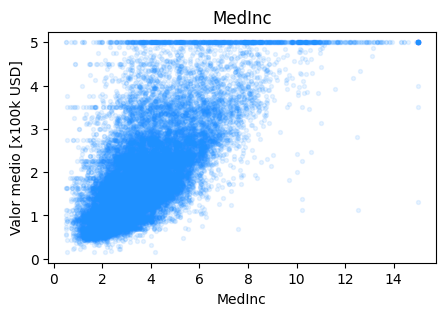

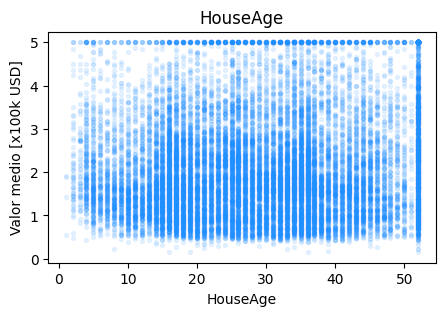

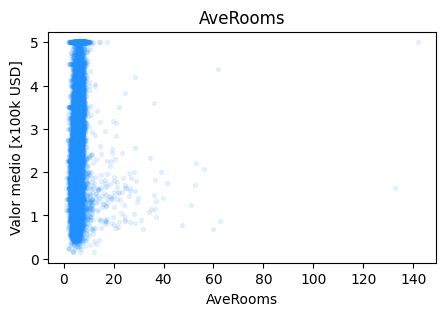

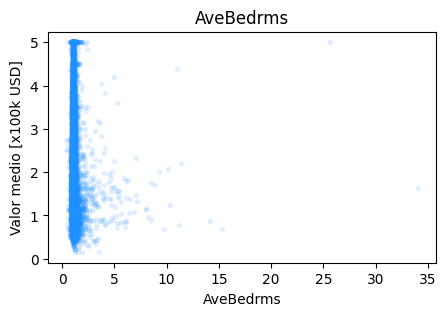

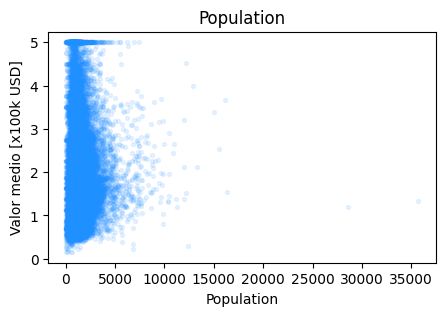

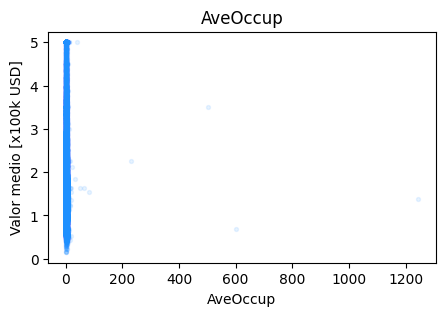

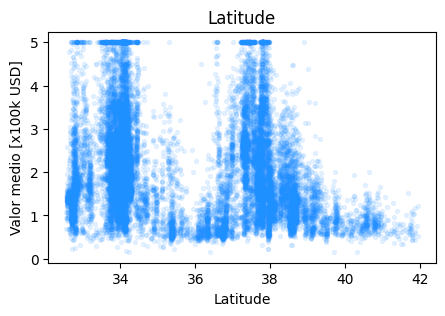

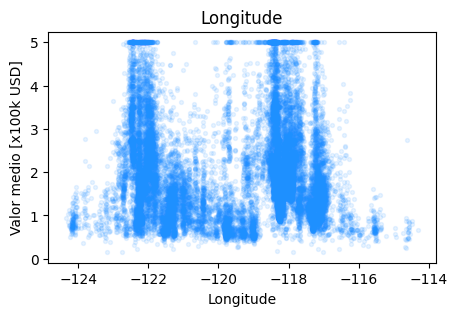

In [9]:
# 1. Una grafica por cada atributo contra la variable objetivo.
feature_names = california['feature_names']

for i in range(len(feature_names)):
    plt.figure(figsize=(5, 3))
    plt.scatter(X[:, i], y, alpha=0.1, s=8, color="dodgerblue")
    plt.xlabel(feature_names[i])
    plt.ylabel("Valor medio [x100k USD]")
    plt.title(feature_names[i])
    plt.show()

### 2. Lectura de las gráficas

Mirando los gráficos a ojo:

- **`MedInc`** es el que tiene la relación más clara: cuando sube el ingreso, sube el valor de la vivienda. Es el atributo más informativo.
- **`Latitude` y `Longitude`** no muestran una recta, pero sí zonas: hay regiones con valores altos y otras bajas. La ubicación parece importar bastante.
- **`AveRooms`** tiene una tendencia positiva pero con mucha dispersión.
- **`HouseAge`** se ve difusa, sin una relación marcada.
- **`AveBedrms`, `Population`, `AveOccup`** se ven como nubes planas, sin mucha relación con el precio.

### 3. Ranking de importancia (a ojo)

1. **`MedInc`** — la relación más clara.
2. **`Latitude` + `Longitude`** — la ubicación; no es lineal pero se ven zonas.
3. **`AveRooms`** — aporta algo (tamaño de la vivienda).
4. **`HouseAge`** — poco.

El resto (`AveBedrms`, `Population`, `AveOccup`) los veo poco informativos.

## Ejercicio 3: Regresión Lineal

1. Seleccione **un solo atributo** que considere puede ser el más apropiado.
2. Instancie una regresión lineal de **scikit-learn**, y entrénela usando sólo el atributo seleccionado.
3. Evalúe, calculando error cuadrático medio para los conjuntos de entrenamiento y evaluación.
4. Grafique el modelo resultante, junto con los puntos de entrenamiento y evaluación.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se puede obtener un error en test menor a 50.

In [10]:
# 1. Elijo el atributo que se ve mas informativo en el Ej2: MedInc.
feature = 'MedInc'
selector = (np.array(california['feature_names']) == feature)

X_train_f = X_train[:, selector]
X_test_f = X_test[:, selector]
X_train_f.shape, X_test_f.shape

((16512, 1), (4128, 1))

In [11]:
X_train_f[:5]

array([[4.2386],
       [4.3898],
       [3.9333],
       [1.4653],
       [3.1765]])

In [12]:
# 2. Instanciar y entrenar la regresion lineal con un solo atributo.
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_f, y_train)
print("pendiente:", model.coef_[0])
print("ordenada:", model.intercept_)

pendiente: 0.4203217769894005
ordenada: 0.4432063522765708


In [13]:
# 3. Predecir y calcular el MSE en train y test.
from sklearn.metrics import mean_squared_error

y_pred_train = model.predict(X_train_f)
y_pred_test = model.predict(X_test_f)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
print("MSE train:", round(mse_train, 4))
print("MSE test: ", round(mse_test, 4))

MSE train: 0.6961
MSE test:  0.7215


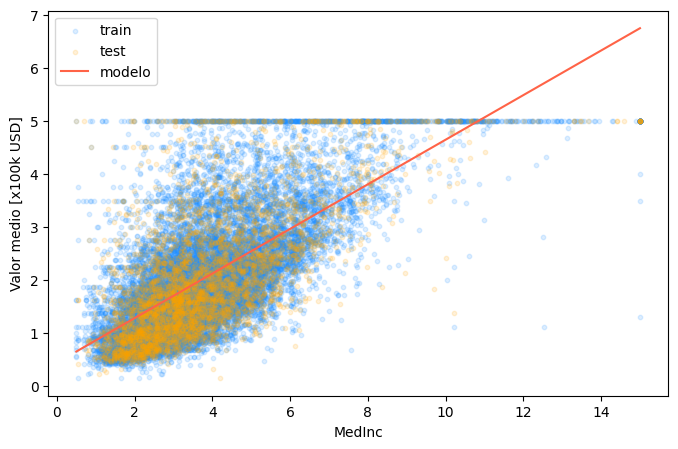

In [14]:
# 4. Graficar el modelo con los puntos de train y test.
x_start = min(np.min(X_train_f), np.min(X_test_f))
x_end = max(np.max(X_train_f), np.max(X_test_f))
x = np.linspace(x_start, x_end, 200).reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_train_f, y_train, alpha=0.15, s=10, color="dodgerblue", label="train")
plt.scatter(X_test_f, y_test, alpha=0.15, s=10, color="orange", label="test")
plt.plot(x, model.predict(x), color="tomato", label="modelo")
plt.xlabel(feature)
plt.ylabel("Valor medio [x100k USD]")
plt.legend()
plt.show()

### 5. Interpretación

El MSE en train (≈0.70) y en test (≈0.72) son parecidos, así que el modelo **no sobreajusta**: generaliza casi igual que entrena. Pero el error es alto y la nube de puntos tiene mucha dispersión que una recta no puede capturar. Es un caso de **underfitting**: un solo atributo y una recta se quedan cortos.

En el gráfico se ve una línea horizontal de puntos en y = 5.0: es porque el target está **truncado en 5.0** (los valores por encima de \$500k se cortan ahí), y la recta no puede ajustar esa zona.

## Ejercicio 4: Regresión Polinomial

En este ejercicio deben entrenar regresiones polinomiales de diferente complejidad, siempre usando **scikit-learn**.

Deben usar **el mismo atributo** seleccionado para el ejercicio anterior.

1. Para varios grados de polinomio, haga lo siguiente:
    1. Instancie y entrene una regresión polinomial.
    2. Prediga y calcule error en entrenamiento y evaluación. Imprima los valores.
    3. Guarde los errores en una lista.
2. Grafique las curvas de error en términos del grado del polinomio.
3. Interprete la curva, identificando el punto en que comienza a haber sobreajuste, si lo hay.
4. Seleccione el modelo que mejor funcione, y grafique el modelo conjuntamente con los puntos.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se pueden obtener errores en test menores a 40 e incluso a 35.

In [15]:
# 1. Regresion polinomial de varios grados, usando el mismo atributo (MedInc).
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

grados = range(1, 7)
errores_train = []
errores_test = []

for d in grados:
    modelo = make_pipeline(PolynomialFeatures(d), LinearRegression(fit_intercept=False))
    modelo.fit(X_train_f, y_train)
    mtr = mean_squared_error(y_train, modelo.predict(X_train_f))
    mte = mean_squared_error(y_test, modelo.predict(X_test_f))
    errores_train.append(mtr)
    errores_test.append(mte)
    print("grado", d, "- MSE train:", round(mtr, 4), "| MSE test:", round(mte, 4))

grado 1 - MSE train: 0.6961 | MSE test: 0.7215
grado 2 - MSE train: 0.6895 | MSE test: 0.7174
grado 3 - MSE train: 0.6782 | MSE test: 0.7081
grado 4 - MSE train: 0.6781 | MSE test: 0.708
grado 5 - MSE train: 0.678 | MSE test: 0.708
grado 6 - MSE train: 0.6761 | MSE test: 0.7068


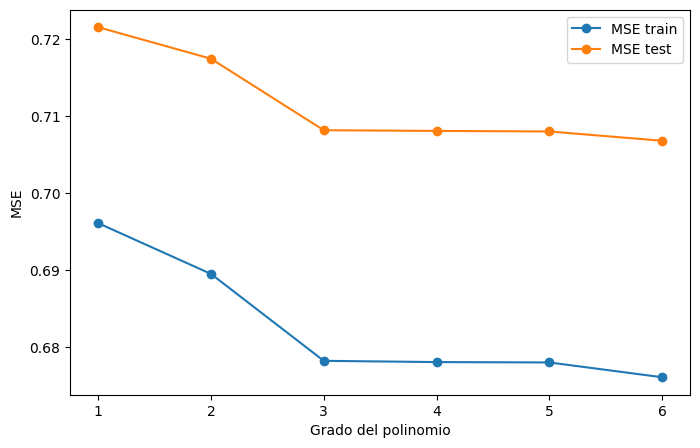

In [16]:
# 2. Curvas de error segun el grado del polinomio.
plt.figure(figsize=(8, 5))
plt.plot(list(grados), errores_train, "o-", label="MSE train")
plt.plot(list(grados), errores_test, "o-", label="MSE test")
plt.xlabel("Grado del polinomio")
plt.ylabel("MSE")
plt.legend()
plt.show()

### 3. ¿Dónde empieza el sobreajuste?

Con un solo atributo, el error de train y el de test bajan juntos y muy poco (de 0.72 a 0.70). La diferencia entre train y test se mantiene chica, así que **no aparece sobreajuste** en este rango de grados. El modelo no mejora mucho porque `MedInc` solo no alcanza para explicar el precio: sigue habiendo underfitting. El sobreajuste recién va a aparecer cuando usemos muchos atributos (Ej6).

grado elegido: 3
MSE test: 0.7081


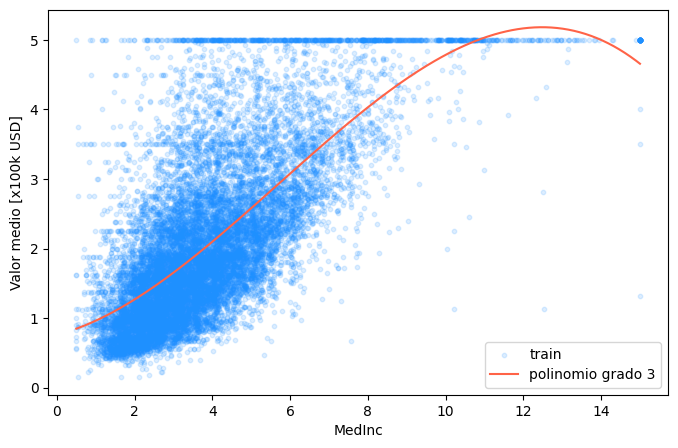

In [17]:
# 4. Elijo el mejor grado. Como a partir del grado 3 las mejoras son muy chicas,
#    me quedo con el grado 3 (modelo mas simple que ya captura la curva).
mejor_grado = 3
mejor_modelo = make_pipeline(PolynomialFeatures(mejor_grado), LinearRegression(fit_intercept=False))
mejor_modelo.fit(X_train_f, y_train)
print("grado elegido:", mejor_grado)
print("MSE test:", round(mean_squared_error(y_test, mejor_modelo.predict(X_test_f)), 4))

xx = np.linspace(np.min(X_train_f), np.max(X_train_f), 300).reshape(-1, 1)
plt.figure(figsize=(8, 5))
plt.scatter(X_train_f, y_train, alpha=0.15, s=10, color="dodgerblue", label="train")
plt.plot(xx, mejor_modelo.predict(xx), color="tomato", label="polinomio grado 3")
plt.xlabel(feature)
plt.ylabel("Valor medio [x100k USD]")
plt.legend()
plt.show()

### 5. Interpretación del mejor modelo

El polinomio de grado 3 mejora muy poco respecto de la recta (de 0.72 a 0.71 en test). Captura algo de la curvatura, pero el problema sigue siendo que con un solo atributo no hay suficiente información. La conclusión es que para mejorar de verdad no hace falta más complejidad, sino **más atributos** (eso es lo que probamos en el Ej5).

## Ejercicio 5: Regresión con más de un Atributo

En este ejercicio deben entrenar regresiones que toman más de un atributo de entrada.

1. Seleccione **dos o tres atributos** entre los más relevantes encontrados en el ejercicio 2.
2. Repita el ejercicio anterior, pero usando los atributos seleccionados. No hace falta graficar el modelo final.
3. Interprete el resultado y compare con los ejercicios anteriores. ¿Se obtuvieron mejores modelos? ¿Porqué?

In [18]:
# 1. Elijo los atributos que se veian mas relevantes en el Ej2: MedInc + la ubicacion.
selector = (
    (np.array(california['feature_names']) == 'MedInc') |
    (np.array(california['feature_names']) == 'Latitude') |
    (np.array(california['feature_names']) == 'Longitude')
)
X_train_fs = X_train[:, selector]
X_test_fs = X_test[:, selector]
X_train_fs.shape, X_test_fs.shape

((16512, 3), (4128, 3))

In [19]:
# 2. Repito con estos atributos, probando algunos grados.
for d in [1, 2, 3]:
    modelo = make_pipeline(PolynomialFeatures(d), LinearRegression(fit_intercept=False))
    modelo.fit(X_train_fs, y_train)
    mte = mean_squared_error(y_test, modelo.predict(X_test_fs))
    print("grado", d, "- MSE test:", round(mte, 4))

grado 1 - MSE test: 0.565
grado 2 - MSE test: 0.536
grado 3 - MSE test: 0.5163


### 3. Comparación con los ejercicios anteriores

| Modelo | MSE test |
|---|---|
| Lineal `MedInc` (Ej3) | ≈ 0.72 |
| Polinomial `MedInc` grado 3 (Ej4) | ≈ 0.71 |
| **Lineal `MedInc`+`Latitude`+`Longitude` (Ej5)** | **≈ 0.57** |

Sí, se obtuvieron **mejores modelos**. El salto grande (de 0.72 a 0.57) lo da agregar la **ubicación** (`Latitude` y `Longitude`), no subir el grado. El motivo es simple: la latitud y la longitud aportan información que `MedInc` no tiene (por ejemplo, zonas costeras más caras). Con un solo atributo el modelo ignoraba todo eso. Subir el grado del polinomio casi no ayudaba; sumar atributos relevantes sí.

## Más ejercicios (opcionales)

### Ejercicio 6: A Todo Feature

Entrene y evalúe regresiones pero utilizando todos los atributos de entrada (va a andar mucho más lento). Estudie los resultados.

### Ejercicio 7: Regularización

Entrene y evalúe regresiones con regularización "ridge". Deberá probar distintos valores de "alpha" (fuerza de la regularización). ¿Mejoran los resultados?


### Desarrollo del Ejercicio 6 — A Todo Feature

Entreno usando los 8 atributos y comparo grado 1 (lineal) contra grado 2.

In [20]:
# Regresion con todos los atributos: grado 1 vs grado 2.
for d in [1, 2]:
    modelo = make_pipeline(PolynomialFeatures(d), LinearRegression(fit_intercept=False))
    modelo.fit(X_train, y_train)
    mtr = mean_squared_error(y_train, modelo.predict(X_train))
    mte = mean_squared_error(y_test, modelo.predict(X_test))
    print("grado", d, "- MSE train:", round(mtr, 4), "| MSE test:", round(mte, 4))

grado 1 - MSE train: 0.5234 | MSE test: 0.529
grado 2 - MSE train: 0.4197 | MSE test: 2.7638


**Resultado e interpretación**

Con todos los atributos:

- **Grado 1 (lineal):** MSE test ≈ 0.53. Es el mejor resultado hasta ahora, porque ahora el modelo usa toda la información disponible.
- **Grado 2:** el MSE de train baja, pero el de test **sube muchísimo** (≈ 2.76). Acá aparece el **sobreajuste**: con 8 atributos y grado 2 se generan muchas columnas (cuadrados y combinaciones de los atributos), el modelo memoriza el train pero falla en test.

Resumiendo el TP: un atributo da underfitting; sumar atributos relevantes mejora bastante; demasiada complejidad (grado 2 con todo) lleva al overfitting. El mejor modelo simple fue el **lineal con todos los atributos** (≈ 0.53).

### Desarrollo del Ejercicio 7 — Regularización Ridge

En el Ej6 vimos que el modelo de grado 2 con todos los atributos sobreajusta (MSE test ≈ 2.76). Ridge agrega una penalización a los coeficientes grandes (controlada por `alpha`), así que debería ayudar a controlar ese sobreajuste. Pruebo varios valores de `alpha`.

In [21]:
# Ridge sobre el polinomio de grado 2 con todos los atributos.
from sklearn.linear_model import Ridge

alphas = [0.01, 0.1, 1, 10, 100, 1000]
errores_ridge = []
for a in alphas:
    modelo = make_pipeline(PolynomialFeatures(2), Ridge(alpha=a))
    modelo.fit(X_train, y_train)
    mte = mean_squared_error(y_test, modelo.predict(X_test))
    errores_ridge.append(mte)
    print("alpha", a, "- MSE test:", round(mte, 4))

alpha 0.01 - MSE test: 2.7976
alpha 0.1 - MSE test: 2.7865
alpha 1 - MSE test: 2.2904
alpha 10 - MSE test: 1.2929
alpha 100 - MSE test: 0.8694
alpha 1000 - MSE test: 0.5048


/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.99614e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.99614e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.55523e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.81921e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarnin

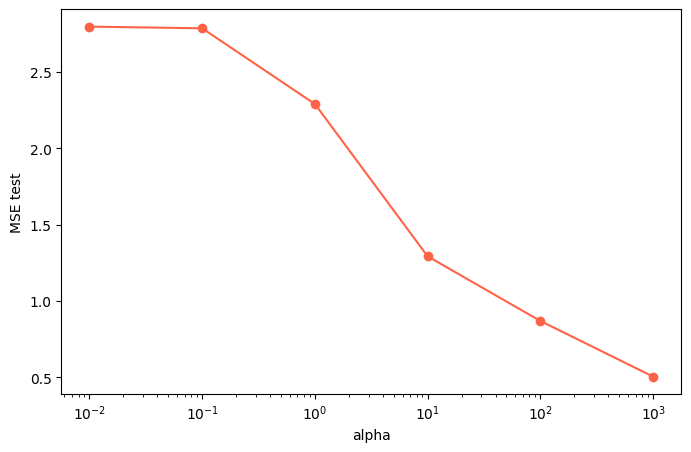

In [22]:
# El MSE test segun alpha (escala logaritmica en x porque los alpha crecen por multiplos).
plt.figure(figsize=(8, 5))
plt.semilogx(alphas, errores_ridge, "o-", color="tomato")
plt.xlabel("alpha")
plt.ylabel("MSE test")
plt.show()

### Interpretación del Ejercicio 7

Sí, Ridge **mejora** los resultados. Sin regularizar, el modelo de grado 2 con todos los atributos daba MSE test ≈ 2.76. A medida que sube `alpha`, el error de test baja, y con `alpha = 1000` llega a ≈ 0.50, controlando el sobreajuste.

Algo que noté: hace falta un `alpha` bastante grande (1000) para que la regularización funcione bien. Esto pasa porque los atributos tienen escalas muy distintas (por ejemplo `Population` toma valores de miles y `AveRooms` valores chicos), y la penalización de Ridge depende de esas escalas. Una forma de mejorar esto sería normalizar los atributos antes de entrenar, pero eso es un tema que se ve más adelante en el curso.

---
## Reflexión sobre el proceso de trabajo

Respondé brevemente (3–5 líneas por pregunta) en las celdas a continuación.

**a) ¿Usaste alguna herramienta de IA (ChatGPT, Claude, Copilot, etc.) durante este trabajo? ¿Para qué?**

*Tu respuesta (escribila VOS, con la verdad):*

Guía para no quedarte en blanco:
- ¿Usaste IA? ¿Cuál(es)?
- ¿Para qué exactamente? (¿generar código, discutir el enfoque, depurar, interpretar resultados?)
- ¿Qué hiciste vos y qué delegaste?

**b) Si usaste IA: ¿qué tuviste que entender vos para validar lo que te produjo? ¿Hubo algo que te pareció incorrecto o que tuviste que corregir?**

*Tu respuesta (escribila VOS):*

Guía:
- ¿Qué conceptos tuviste que entender para validar lo que te dio la IA? (ej.: las unidades del target, bias vs. varianza, qué es overfitting, por qué subir el grado no siempre mejora).
- ¿Hubo algo que la IA te dijo y resultó incorrecto, o que tuviste que corregir?
- ¿Cómo verificaste que un número/resultado era correcto?

**c) Si no usaste IA: ¿qué recursos o estrategias usaste cuando te trabaste?**

*(Solo si NO usaste IA.) ¿Qué recursos o estrategias usaste cuando te trabaste?*